# Домашнее задание "Однофакторный дисперсионный анализ (ANOVA)"

**Инструкции:**
- Скачайте этот файл и заполните ячейки с кодом и текстовыми выводами.
- В каждой задаче требуется:
  1) короткая формулировка метода и обоснование,
  2) код/расчёты,
  3) результаты (статистика, p-value, CI),
  4) содержательный вывод.
- Используйте `scipy`, `statsmodels`, `pingouin` или `scikit-posthocs` по желанию. При нарушении допущений объясните, какие альтернативы применили.

Формат сдачи: `.ipynb` с заполненными ячейками и выводами.

In [94]:
# дополняйте ячейку любыми импортами по желанию!
import numpy as np
import pandas as pd
import scipy.stats as st
from scipy.stats import norm
from scipy import stats
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW
import pingouin as pg
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.power import FTestAnovaPower


### Задание 1. Сопоставление статистик

Вам предложены описания ситуаций и статистических процедур. Для каждой ситуации укажите наилучшую применимую статистику из списка: `z-test`, `t-test`, `Welch t-test`, `F-test` (сравнение дисперсий), `χ^2` (goodness-of-fit), `ANOVA (one-way)`, `Tukey HSD`, `Levene`.

Ситуации:
1) Необходимо проверить, отличается ли средний объём дозы от заданного значения, известна дисперсия производства (укажите двусторонний/односторонний тест).
2) Сравнить средние двух независимых групп при неизвестных, но равных дисперсиях.
3) Сравнить средние двух независимых групп при неизвестных и неравных дисперсиях.
4) Оценить, одинаковы ли средние в трёх и более группах.
5) Проверить, согласуются ли наблюдаемые частоты с распределением Пуассона.

**Требуется:** кратко объясните выбор для каждой ситуации (1—2 предложения).


### ответы, рассуждения и выводы

1. Ситуация 1. Наилучшая статистика для данной ситуации - Z-test. Данная статистика используется, в том числе, для проверки отличия выборочного среднего от известного среднего генеральной совокупности, при условии, что дисперсия генеральной совокупности известна заранее. В данном случае тест односторонний, так как мы проверяем отличие среднего значения выборки от теоретического среднего, а не сравниваем средние двух независимых выборок.

2. Ситуация 2. Наилучшая статистика для данной ситуации - t-test. Данная статистика используется, в том числе, для проверки различий между средними значениям выборок, когда дисперсия генеральной совокупности неизвестна, а дисперсии групп равны, а также для применения этой статистики выборки должны быть независимы, как в нашем случае.

3. Ситуация 3. Наилучшая статистика для данной ситуации - Welch t-test. Данная статистика используется, в тех же случаях, что и t-test, но когда дисперсии групп не равны.

4. Ситуация 4. Наилучшая статистика для данной ситуации - ANOVA (one way). Данная статистика используется для определения различий (в нашем случае необходимо проверить отсутствие различий) между средними значениями трех или более групп.

5. Ситуация 5. Наилучшая статистика для данной ситуации - $\chi^2$ (goodness-of-fit). Данная статистика используется для определения насколько хорошо наблюдаемые данные соответствуют ожидаемому теоретическому распределению, в нашем случае распределению Пуассона.

### Задание 2. Тест для дозатора (z-test, двусторонний)

Инженерная задача. Дозатор рассчитывает среднюю дозу 3.00 г. Получено $n=50$ измерений со средним $\overline X=3.005$ и известным стандартным отклонением процесса $\sigma=0.015$.

а) Проведите двусторонний z-тест для проверки $H_0:\,\mu=3.00$ при $\alpha=0.05$.

б) Постройте 95% доверительный интервал для $\mu$.

в) Сделайте практический вывод для инженера: нужно ли перенастраивать дозатор?

**Требуется:** формулы расчёта, численные значения (z_obs, p-value, CI), вывод.


In [95]:
mu0 = 3.00
xbar = 3.005
sigma = 0.015
n = 50
alpha = 0.05
# Ваш код и расчёты

# a) двусторонний z-тест

Z0 = (xbar - mu0)/(sigma/(n**0.5)) # Вычисляем z-статистику

p_value = 2 * (1 - norm.cdf(abs(Z0))) # Вычисляем двусторонний p-value

Z_crit = norm.ppf(1 - alpha / 2) # Вычисляем критическое значение Z для 95% (двусторонний интервал)

print(f"Z-статистика: {Z0:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Критическое значение Z: ±{Z_crit:.4f}")

if p_value < alpha:
    print("Отвергаем H0: средняя доза значимо отличается от 3.00 г")
else:
    print("Не отвергаем H0: данных недостаточно, чтобы считать среднюю дозу отличной от 3.00 г")
    
# б) 95% доверительный интервал

margin = Z_crit * (sigma/(n**0.5)) # Полуширина доверительного интервала

ci_lower = xbar - margin # нижняя граница доверительного интервала
ci_upper = xbar + margin # верхняя граница доверительного интервала

print("95% доверительный интервал для μ: [{:.6f}, {:.6f}] г"
      .format(ci_lower, ci_upper))


Z-статистика: 2.3570
p-value: 0.0184
Критическое значение Z: ±1.9600
Отвергаем H0: средняя доза значимо отличается от 3.00 г
95% доверительный интервал для μ: [3.000842, 3.009158] г


### ответы, рассуждения и выводы

а) При заданном уровне строгости 0,05 мы отвергаем $H_0$, так как есть статистически значимое смещение, p_value < alpha.

б) 95% доверительный интервал для μ: [3.000842, 3.009158], то есть с доверием 95 % истинное среднее дозатора лежит между 3.000842 и 3.009158 г.

в) При заданном уровне строгости среднее значение выборки лежит за пределами доверительного интервала и не соответсвтует теоретическому среднему. Значит дозатор необходимо перенастроить.


   

### Задание 3. Сравнение прочности материалов (t-test vs Welch)

Даны две независимые выборки прочности материалов (в MPa):

| Группа    | Наблюдения                                                                                                |
| :-------- | :-------------------------------------------------------------------------------------------------------- |
| A (n₁=15) | [51.99, 49.45, 52.59, 56.09, 49.06, 49.06, 56.32, 53.07, 48.12, 52.17, 48.15, 48.14, 50.97, 42.35, 43.10] |
| B (n₂=10) | [48.63, 45.92, 53.89, 46.55, 43.53, 60.79, 50.65, 52.41, 43.45, 48.73]                                    |

**Требуется:**

1. Проверить равенство дисперсий с помощью тестов **Levene** и классического **F-test**.
2. В зависимости от результата выполнить либо **pooled t-test**, либо **Welch t-test** для проверки
   $H_0:$ $\mu_A = \mu_B$ при $\alpha = 0.05$.
3. Построить 95% доверительный интервал для разности средних и интерпретировать.
4. Оформить заключение и вывод.


In [96]:
A = np.array([51.99,49.45,52.59,56.09,49.06,49.06,56.32,53.07,48.12,52.17,48.15,48.14,50.97,42.35,43.10])
B = np.array([48.63,45.92,53.89,46.55,43.53,60.79,50.65,52.41,43.45,48.73])

# Ваш код и расчёты

# 1. Проверить равенство дисперсий с помощью тестов **Levene** и классического **F-test**.

# **Levene**

stat_levene, p_levene = stats.levene(A, B, center='mean')

print(f"Levene's Test: Statistic={stat_levene:.4f}, p-value={p_levene:.4f}")

# **F-test**

def f_test_variances(A, B):
    
    var_A = np.var(A, ddof=1)
    var_B = np.var(B, ddof=1)
    
    # Статистика: Большая дисперсия / Меньшая дисперсия
    if var_A > var_B:
        F_stat = var_A / var_B
        df1, df2 = A.size - 1, B.size - 1
    else:
        F_stat = var_B / var_A
        df1, df2 = B.size - 1, A.size - 1
        
    # P-value (двусторонний) = 2 * (1 - CDF)
    p_value = 2 * stats.f.sf(F_stat, df1, df2)
    return F_stat, p_value

F_stat, p_value = f_test_variances(A, B)
print(f"F-test: Statistic={F_stat:.4f}, p-value={p_value:.4f}")

# Выполнение Pooled t-test
alpha = 0.05
t_stat, p_val = stats.ttest_ind(A, B, equal_var=True)

print(f"T-statistic: {t_stat:.4f}")
print(f"T-P-value:     {p_val:.4f}")

if p_val < alpha:
    print("Отвергаем H0: Средние значения различаются.")
else:
    print("Не отвергаем H0: Нет доказательств различия средних.")
    
# 95% доверительный интервал для разности средних

cm = CompareMeans(DescrStatsW(A), DescrStatsW(B)) # Создаем объекты описательной статистики

lower, upper = cm.tconfint_diff(alpha=0.05, alternative='two-sided', usevar='pooled') # Расчет 95% интервала, usevar='pooled' (если дисперсии равны)

print(f"95% CI для разности (Mean1 - Mean2): [{lower:.4f}, {upper:.4f}]")

Levene's Test: Statistic=0.6844, p-value=0.4166
F-test: Statistic=1.7681, p-value=0.3271
T-statistic: 0.3171
T-P-value:     0.7541
Не отвергаем H0: Нет доказательств различия средних.
95% CI для разности (Mean1 - Mean2): [-3.2428, 4.4168]


### ответы, рассуждения и выводы

1. И в тесте Левена, и в F-тесте p-value > 0.05. Это означает, что разброс прочности в группах приблизительно равен. Значит можно использовать классический **pooled t-test**.

2. По результатам расчета **pooled t-test** p_val > alpha, значит $\mu_A = \mu_B$, при $\alpha = 0.05$.

3. Доверительный интервал для разности средних показывает диапазон, в котором с вероятностью 95% находится истинная разница между генеральными совокупностями. В нашем случае интервал содержит "0" [-3.2428, 4.4168], значит разница между группами статистически незначима на уровне значимости 5%, и мы не можем утверждать, что один материал прочнее другого.



### Задание 4. Парные измерения — новая vs старая схема

Эксперимент парного дизайна: каждому прибору (или образцу) до и после изменения схемы измеряется показатель.

Даны пары (старое, новое):

$(12.5, 12.2), (13.1,13.0), (11.8,12.0), (12.9,12.7), (13.5,13.6), (12.0,11.9), (13.2,13.4)$

а) Проверьте нормальность распределения разностей (Shapiro-Wilk).

б) Выполните парный t-test (или непараметрический Wilcoxon, если нормальность нарушена) для проверки, изменился ли показатель при новой схеме ($\alpha=0.05$).

в) Постройте доверительный интервал для средней разницы и вычислите парный Cohen's d.

**Требуется:** расчёты, тест, p-value, CI, эффект и вывод.

In [97]:
old = np.array([12.5,13.1,11.8,12.9,13.5,12.0,13.2])
new = np.array([12.2,13.0,12.0,12.7,13.6,11.9,13.4])

# Ваш код и расчёты

# а) Проверьте нормальность распределения разностей (Shapiro-Wilk).

differences = new - old # Вычисление разностей (d = New - Old)

shapiro_result = stats.shapiro(differences) # Тест Шапиро-Уилка, нулевая гипотеза (H0): Выборка имеет нормальное распределение

print(f"Статистика W: {shapiro_result.statistic:.4f}")
print(f"P-value: {shapiro_result.pvalue:.4f}")

# б) парный t-test для проверки, изменился ли показатель при новой схеме

t_test = stats.ttest_rel(old, new)

print(f"t-statistic: {t_test.statistic:.3f}")
print(f"t_test-p-value: {t_test.pvalue:.3f}")

# в) доверительный интервал для средней разницы и вычислите парный Cohen's d.

n = len(differences)
mean_diff = np.mean(differences) # средняя разность: New - Old
std_diff = np.std(differences, ddof=1) # стандартное отклонение разностей

se = std_diff / np.sqrt(n) # стандартная ошибка
t_crit = stats.t.ppf(0.975, df=n-1) # критическое значение t-распределения 
ci = (mean_diff - t_crit * se, mean_diff + t_crit * se) # доверительный интервал для средней разности

cohens_d = mean_diff / std_diff # размер эффекта Cohen's d

print(f"95% CI для разности: [{ci[0]:.3f}, {ci[1]:.3f}]")
print(f"Cohen's d: {cohens_d:.3f}")

Статистика W: 0.9071
P-value: 0.3758
t-statistic: 0.383
t_test-p-value: 0.715
95% CI для разности: [-0.211, 0.154]
Cohen's d: -0.145


### ответы, рассуждения и выводы

а) При уровне значимости значимости $\alpha = 0.05$, $p\text{-value} = 0.376 > 0.05$, значит нет оснований отвергать нулевую гипотезу о нормальном распределении выборки разностей.

б) Так как распределение разностей согласуется с нормальным распределением, для анализа этих данных можно использовать парный t-test. Проверяем нулевую гипотезу о том, что среднее значение разностей равно 0, то есть изменений нет. Так как $p\text{-value} = 0.715 > 0.05$, у нас нет оснований отвергнуть нулевую гипотезу. Значит статистически значимых различий между показателями приборов до и после изменения схемы не обнаружено.

в)95% доверительный интервал для разности: [-0.211, 0.154], так как интервал включает 0, значит статистически значимой разницы между измерениями нет, подтверждается результат t_test. Значение эффекта Cohen's d -0,145 , это считается малым эффектом, значит практическая значимость изменения схемы минимальна.

### Задание 5. До/после — медицинский пример (paired)

Клиническое исследование: измерен уровень глюкозы у 10 пациентов **до** и **после** приёма нового лекарства.

| Пациент | До (ммоль/л) | После (ммоль/л) |
| :------ | :----------: | :-------------: |
| 1       |      7.1     |       6.6       |
| 2       |      6.8     |       6.4       |
| 3       |      7.5     |       7.1       |
| 4       |      6.9     |       6.5       |
| 5       |      7.3     |       7.2       |
| 6       |      6.5     |       6.3       |
| 7       |      7.0     |       6.6       |
| 8       |      6.7     |       6.4       |
| 9       |      7.2     |       7.0       |
| 10      |      6.9     |       6.4       |


**Требуется:**

а) Проверить нормальность распределения разностей (тест **Shapiro–Wilk**).

б) Если нормальность не отвергается — выполнить **парный t-test** при $\alpha = 0.01$.

в) Если нормальность нарушена — выполнить непараметрический тест **Wilcoxon signed-rank** и сравнить выводы.

**Формат вывода:**
Код, p-values, выводы тестов, практическая интерпретация (снижается ли уровень глюкозы достоверно?).

In [98]:
before = np.array([7.1,6.8,7.5,6.9,7.3,6.5,7.0,6.7,7.2,6.9])
after  = np.array([6.6,6.4,7.1,6.5,7.2,6.3,6.6,6.4,7.0,6.4])

# Ваш код и расчёты

# а) Проверьте нормальность распределения разностей (Shapiro-Wilk).

differences = after - before # Вычисление разностей (d = after - before)

shapiro_result = stats.shapiro(differences) # Тест Шапиро-Уилка, нулевая гипотеза (H0): Выборка имеет нормальное распределение

print(f"Статистика W: {shapiro_result.statistic:.4f}")
print(f"P-value: {shapiro_result.pvalue:.4f}")

# выполнить **парный t-test** при $\alpha = 0.01$.

t_test = stats.ttest_rel(before, after)

print(f"t-statistic: {t_test.statistic:.3f}")
print(f"t_test-p-value: {t_test.pvalue:.5f}")
differences.mean()


Статистика W: 0.8960
P-value: 0.1977
t-statistic: 7.965
t_test-p-value: 0.00002


np.float64(-0.34)

### ответы, рассуждения и выводы

а) Так как $P-value > 0.05$ ($0.1977 > 0.05$), мы не отвергаем нулевую гипотезу. Распределение разностей можно считать нормальным, что позволяет использовать параметрический парный t-test.

б) Проверяем нулевую гипотезу о том, что среднее значение разностей равно 0, то есть изменений нет. Так как $p\text{-value} = 0.00002 < 0.01$, у нас есть основания отвергнуть нулевую гипотезу. Значит статистически значимые различия между показателями уровня глюкозы у пациентов до и после приема нового лекарства есть.

Среднее значение разностей составляет -0.34 ммоль/л. Из результатов теста мы можем сделать вывод о том, что уровень глюкозы достоверно снизился.

### Задание 6. Welch и Games-Howell (симуляция с неравными дисперсиями)

Смоделируйте три группы с одинаковыми средними (например, 10), но существенно разными дисперсиями и неравными размерами выборок (пример: $n_1=20, n_2=8, n_3=5$).

а) Покажите, что классическая ANOVA может ошибочно интерпретировать разницу, если нарушена гомоскедастичность.

б) Выполните Welch ANOVA и пост-hoc Games-Howell.

в) Сравните результаты и сделайте вывод о корректности подходов.

**Требуется:** код симуляции, результаты ANOVA и Welch, таблица post-hoc и вывод.


In [99]:
# Ваш код и расчёты
np.random.seed(12)

# Три группы: средние равны (10), но дисперсии и размеры разные
g1 = np.random.normal(loc=10, scale=1, size=20)
g2 = np.random.normal(loc=10, scale=3, size=8)
g3 = np.random.normal(loc=10, scale=9, size=5)

data = pd.DataFrame({
    'Score': np.concatenate([
        g1,
        g2,
        g3
    ]),
    'Group': ['g1']*20 + ['g2']*8 + ['g3']*5
})

lev_stat, lev_p = stats.levene(g1, g2, g3) # Проверка равенства дисперсий (Levene)

f_stat, f_p = stats.f_oneway(g1, g2, g3) # Классическая ANOVA (F-test)

welch_res = pg.welch_anova(data=data, dv='Score', between='Group') # Welch ANOVA 

posthoc_results = pg.pairwise_gameshowell(data=data, dv='Score', between='Group')

print(f"Средние: G1={g1.mean():.2f}, G2={g2.mean():.2f}, G3={g3.mean():.2f}")
print(f"Стд.откл: G1={g1.std(ddof=1):.2f}, G2={g2.std(ddof=1):.2f}, G3={g3.std(ddof=1):.2f}")
print("-" * 30)
print(f"Levene test p-value: {lev_p:.5f} (Дисперсии не равны)")
print("-" * 30)
print(f"Classic ANOVA p-value: {f_p:.5f}")
print("-" * 30)
print(f"Welch ANOVA p-value:   {welch_res['p-unc'][0]:.5f}")
print("-" * 30)
print(f"posthoc p-value:")
posthoc_results


Средние: G1=10.04, G2=8.11, G3=4.21
Стд.откл: G1=1.14, G2=3.60, G3=8.53
------------------------------
Levene test p-value: 0.00098 (Дисперсии не равны)
------------------------------
Classic ANOVA p-value: 0.01199
------------------------------
Welch ANOVA p-value:   0.20037
------------------------------
posthoc p-value:


,A,B,mean(A),mean(B),diff,se,T,df,pval,hedges
0,g1,g2,10.037798,8.114225,1.923573,1.296783,1.483342,7.574690,0.350504,0.886423
1,g1,g3,10.037798,4.206514,5.831284,3.824909,1.524555,4.036064,0.372047,1.520873
2,g2,g3,8.114225,4.206514,3.907711,4.022499,0.971464,4.902461,0.624463,0.617019


### ответы, рассуждения и выводы
а) Из-за большого разброса и малого размера выборки, выборочное среднее g3 сильно отличается от теоретического 4,21 от 10. Классическая Annova рассчитывает одну общую дисперсию для всех групп, усредняя их индивидуальные дисперсии. В результате, интерпретируя значение Classic ANOVA p-value: 0.01199 < 0,05, можно сделать ошибочный вывод о наличии статистически значимых  различий между средними значениями в группах.

б) Welch ANOVA не пытается найти усредненную дисперсию. Она рассчитывает статистику, используя индивидуальную дисперсию каждой группы отдельно. Welch ANOVA p-value:   0.20037 > 0.05, значит можно сделать вывод об отсутствии статистически значимых различий между средними различиями групп. Games-Howell post-hoc используется для попарного сравнения групп. 

В случаях, когда в группе выборок с одинаковые среднимие , но существенно разнымые дисперсии и неравные размеры выборок, Классическая Annova показывает некорректные результаты, и нужно использовать Welch ANOVA.

### Задание 7. ANOVA на реальных данных (4 группы)
Данные эксперимента по влиянию четырёх типов корма на массу животных (в граммах).
Каждая группа содержит по 6 наблюдений.

| Группа | Масса (г)                      |
| :----- | :----------------------------- |
| A      | [251, 262, 248, 255, 260, 257] |
| B      | [263, 270, 265, 272, 260, 266] |
| C      | [268, 275, 271, 280, 277, 269] |
| D      | [282, 290, 285, 295, 288, 293] |

**Требуется:**

а) Выполнить графическую визуализацию (boxplots и точки). Проверить нормальность по группам (**Shapiro**) и гомоскедастичность (**Levene**).

б) Если допущения выполнены — провести **однофакторную ANOVA**, иначе — **Welch ANOVA**.

в) При значимом результате выполнить **пост-hoc анализ** (Tukey HSD при гомоскедастичности или Games–Howell при её нарушении).

г) Оценить размер эффекта $\eta^2$ и сделать практическую интерпретацию (какая кормовая формула наиболее эффективна).


C:\Users\troyd\AppData\Local\Temp\ipykernel_18800\712505188.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Value', data=df_long,


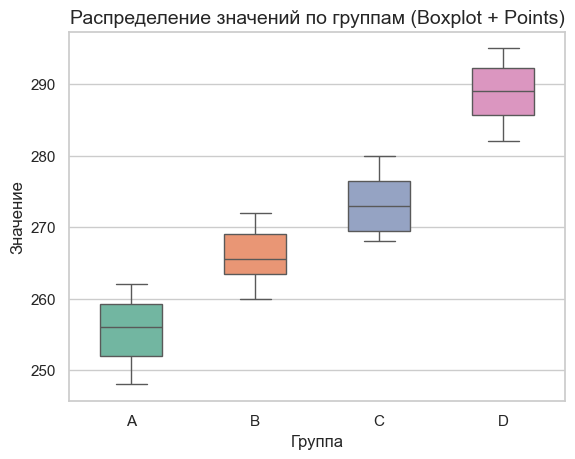

--- Тест Шапиро-Уилка (Нормальность) ---
Группа A: W=0.9682, p-value=0.8799
  -> Распределение нормальное (p > 0.05)
Группа B: W=0.9738, p-value=0.9168
  -> Распределение нормальное (p > 0.05)
Группа C: W=0.9387, p-value=0.6488
  -> Распределение нормальное (p > 0.05)
Группа D: W=0.9781, p-value=0.9415
  -> Распределение нормальное (p > 0.05)

--- Тест Левена (Гомоскедастичность) ---
Статистика=0.1291, p-value=0.9417
-> Дисперсии равны (p > 0.05)
------------------------------
F-statistic: 49.9246
p-value: 1.7997e-09
-> Различия между группами статистически значимы (p < 0.05)
------------------------------
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     A      B     10.5 0.0064  2.6524 18.3476   True
     A      C  17.8333    0.0  9.9858 25.6809   True
     A      D  33.3333    0.0 25.4858 41.1809   True
     B      C   7.3333 0.0723 -0.5142 15.1809  False
     B      D  

In [100]:
A = [251,262,248,255,260,257]
B = [263,270,265,272,260,266]
C = [268,275,271,280,277,269]
D = [282,290,285,295,288,293]

# Ваш код и расчёты

# а) Выполнить графическую визуализацию (boxplots и точки). Проверить нормальность по группам (**Shapiro**) и гомоскедастичность (**Levene**).
df = pd.DataFrame(data = {
    'A': [251, 262, 248, 255, 260, 257],
    'B': [263, 270, 265, 272, 260, 266],
    'C': [268, 275, 271, 280, 277, 269],
    'D': [282, 290, 285, 295, 288, 293]
})
df_long = df.melt(var_name='Group', value_name='Value')

sns.boxplot(x='Group', y='Value', data=df_long, 
            palette="Set2", width=0.5, showfliers=False)
plt.title('Распределение значений по группам (Boxplot + Points)', fontsize=14)
plt.xlabel('Группа', fontsize=12)
plt.ylabel('Значение', fontsize=12)

plt.show()

print("--- Тест Шапиро-Уилка (Нормальность) ---")
# H0: Выборка распределена нормально
# Если p-value > 0.05, не отклоняем H0 (считаем распределение нормальным)
for col in df.columns:
    stat, p_value = stats.shapiro(df[col])
    print(f"Группа {col}: W={stat:.4f}, p-value={p_value:.4f}")
    if p_value > 0.05:
        print(f"  -> Распределение нормальное (p > 0.05)")
    else:
        print(f"  -> Распределение НЕ нормальное (p < 0.05)")

print("\n--- Тест Левена (Гомоскедастичность) ---")
# H0: Дисперсии групп равны
# Если p-value > 0.05, не отклоняем H0 (считаем дисперсии равными)
stat_levene, p_levene = stats.levene(df['A'], df['B'], df['C'], df['D'])

print(f"Статистика={stat_levene:.4f}, p-value={p_levene:.4f}")
if p_levene > 0.05:
    print("-> Дисперсии равны (p > 0.05)")
else:
    print("-> Дисперсии различаются (p < 0.05)")
    
# б) провести **однофакторную ANOVA**

# Выполнение однофакторного дисперсионного анализа
f_stat, p_value = stats.f_oneway(df['A'], df['B'], df['C'], df['D'])

print("-" * 30)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4e}")
if p_value < 0.05:
    print("-> Различия между группами статистически значимы (p < 0.05)")
else:
    print("-> Статистически значимых различий нет")
    
    
# в) Выполнение теста Тьюки
tukey = pairwise_tukeyhsd(endog=df_long['Value'], groups=df_long['Group'], alpha=0.05)
print("-" * 30)
print(tukey)

# г) Оценить размер эффекта $\eta^2$

# Расчет общей средней (Grand Mean)
grand_mean = df_long['Value'].mean()

# Расчет SS_total (Общая сумма квадратов: сумма квадратов отклонений каждого наблюдения от общей средней)
ss_total = ((df_long['Value'] - grand_mean) ** 2).sum()

# Расчет SS_between (Межгрупповая сумма квадратов: взвешенная сумма квадратов отклонений средних групп от общей средней)
group_means = df.mean()
n_per_group = len(df) 
ss_between = sum(n_per_group * (group_means - grand_mean) ** 2)

# Расчет Eta-squared
eta_squared = ss_between / ss_total

print("-" * 30)
print(f"Eta-squared (η²): {eta_squared:.4f}")

### ответы, рассуждения и выводы

а) Нормальность по группам (**Shapiro**) подтверждается, значения p-value > 0.05 по всем группам. Гомоскедастичность (**Levene**), то есть равенство дисперсий, также подтверждается, p-value=0.9417 > 0.05.

б) Так как предположения о нормальности и гомоскедатичности верны — проводим **однофакторную ANOVA**. p-value: 0,0000000018 < 0,05, значит между группами присутствуют статистически значимые различия.

в) Выполняем **пост-hoc анализ** Tukey HSD при гомоскедастичности, и значимых различиях. Данный анализ показывает различия между группами попарно. Группа D показывает наиболее статистически значимые отличие от всех остальных групп (p-adj < 0.05 при сравнении D-A, D-B, D-C), значение p-adj минимально.

г) Полученное значение $\eta^2 = 0.882$ является очень большим. Согласно общепринятым правилам (Cohen): $\eta^2 > 0.14$ считается большим эффектом. В данном случае 88.2% изменений в показателях объясняется именно типом кормовой формулы, а не случайными факторами или индивидуальными особенностями особей. Это говорит о том, что выбор корма критически важен. Наиболее эффективной является кормовая формула D, это видно по визуализации, а также подтверждается тестами.

### Задание 8. Планирование эксперимента: размер выборки и мощность

Планируется эксперимент с $l = 4$ группами. Требуется обеспечить мощность $1 - \beta = 0.8$
для обнаружения разницы $\Delta = 0.5\sigma$ между любыми парами групп
(равный размер групп $n$), при $\alpha = 0.05$.

**Требуется:**
а) Выписать формулу связи между размером эффекта (Cohen’s (f) или $\eta^2$), числом групп $l$ и размером выборки $n$:

$$
f = \sqrt{\frac{\eta^2}{1 - \eta^2}}, \quad \eta^2 = \frac{f^2}{1 + f^2}.
$$

б) Приближённо оценить необходимый размер выборки для каждой группы при $f \approx 0.25$ (средний эффект по Cohen).

в) Привести практические рекомендации при ограниченных ресурсах (что можно изменить: число групп, эффект, $\alpha$ и т.п.).

> Подсказка: можно использовать модуль `from statsmodels.stats.power import FTestAnovaPower`

In [101]:
alpha = 0.05
power = 0.8
f = 0.25
k = 4

# Ваш код и расчёты

analysis = FTestAnovaPower()
required_nobs = analysis.solve_power(
    effect_size=f,
    nobs=None,          # Искомый параметр
    alpha=alpha,
    power=power,
    k_groups=k
)

print(f"Общий необходимый размер выборки (nobs): {np.ceil(required_nobs)}")
print(f"Размер выборки на каждую группу: {np.ceil(required_nobs / k)}")



Общий необходимый размер выборки (nobs): 179.0
Размер выборки на каждую группу: 45.0


### ответы, рассуждения и выводы

а) Для однофакторного дисперсионного анализа (One-Way ANOVA) с равным количеством наблюдений в группах связь выражается через параметр нецентральности $\lambda$, формула выглядит так:

$\lambda = f^2 * l * n$, где

$\lambda$ параметр нецентральности $F$-распределения.

f — размер эффекта Cohen’s f.

l — число групп.

n — размер выборки в одной группе.

$n = \frac{\lambda}{f^2 * l}$

В данной формуле нам неизвестно значение $\lambda$. Дело в том, что не существует одного фиксированного значения $\lambda$. Критическое значение $F$-критерия зависит от степеней свободы ($df_2 = l(n-1)$), а степени свободы зависят от искомого $n$. Получается замкнутый круг: чтобы найти $n$, нужно $\lambda$, а чтобы найти точное $\lambda$, нужно знать $n$. Поэтому на практике это уравнение решается итеративно (подбором). Например через statsmodels.stats.power.FTestAnovaPower.


б) При $f \approx 0.25$ (средний эффект по Cohen) необходимый размер выборки для каждой группы - 45.



### Полезные подсказки и библиотеки
- Проверки: `scipy.stats.shapiro`, `scipy.stats.levene`, `scipy.stats.ttest_ind`, `scipy.stats.ttest_rel`, `scipy.stats.wilcoxon`.
- ANOVA: `statsmodels.formula.api` (ols + anova_lm), `pingouin.anova`, `scipy` (ограничено).
- Post-hoc: `statsmodels.stats.multicomp.pairwise_tukeyhsd`, `scikit-posthocs` для Games-Howell.
- Power analysis: `statsmodels.stats.power.FTestAnovaPower`.

Удачи! Сохраните ноутбук, перезапустите все ячейки от начала до конца и прикрепите файл как ответ.